Running PnP with flow map denoisers...
  t = 0.45...
  t = 0.72...
  t = 1.00...
Done.
t=0.45: var_ratio=0.430, MSE=1.276
t=0.72: var_ratio=0.702, MSE=1.391
t=1.00: var_ratio=0.898, MSE=1.533
Figure v5 saved.


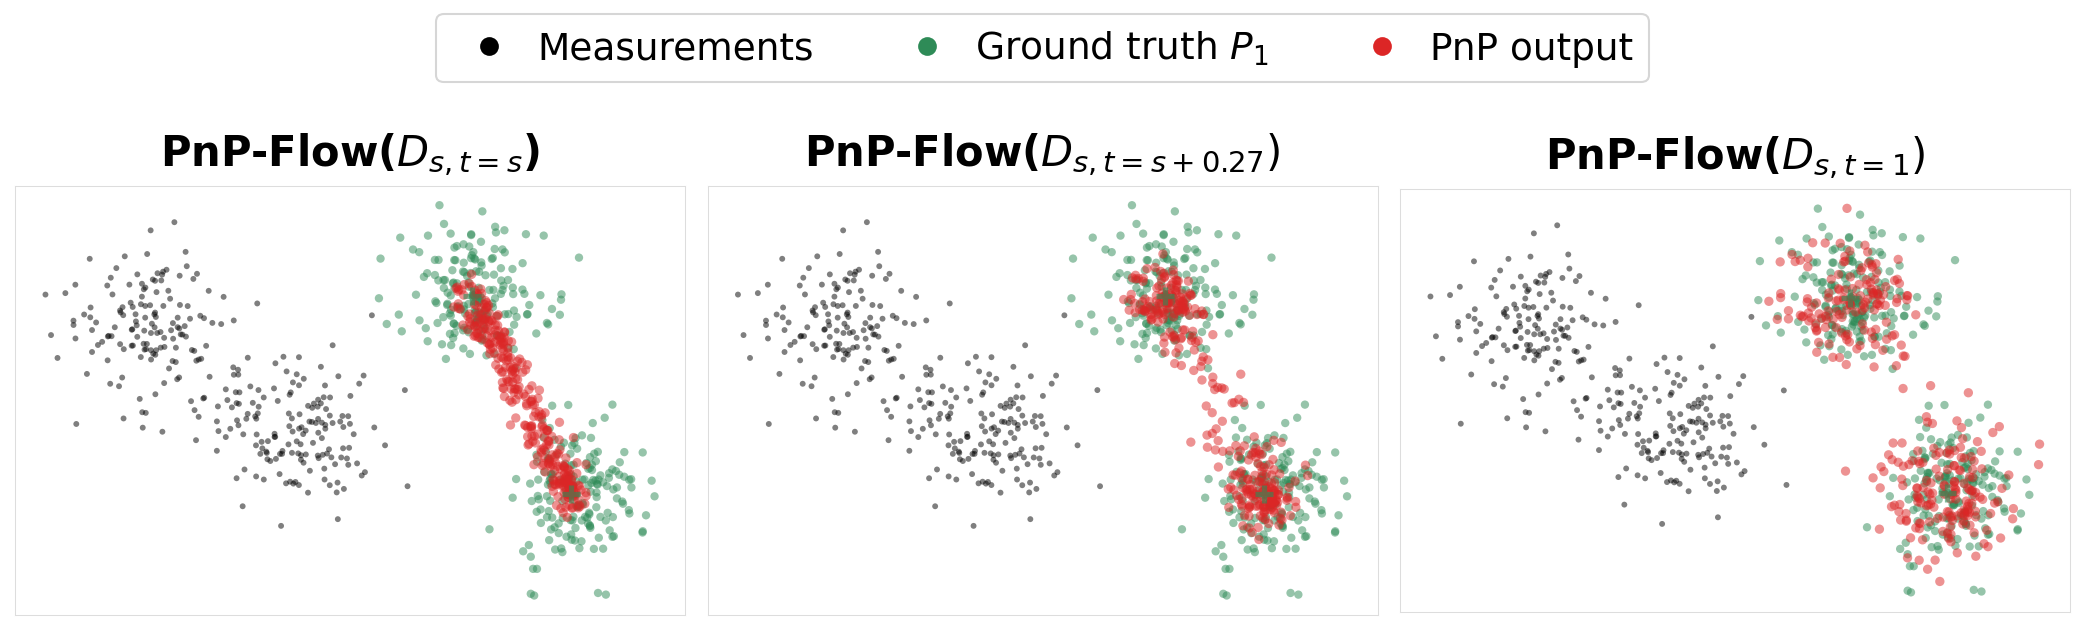

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

np.random.seed(42)

# =============================================================================
# Setup: Mixture of Gaussians P1
# =============================================================================
mu_a = np.array([4.5, 3.5])
mu_b = np.array([3.5, 5.5])
sigma_c = 0.35

n_pts = 350
labels_mix = np.random.binomial(1, 0.5, n_pts)
x1_samples = np.where(labels_mix[:, None],
                       mu_b + sigma_c * np.random.randn(n_pts, 2),
                       mu_a + sigma_c * np.random.randn(n_pts, 2))
x0_samples = np.random.randn(n_pts, 2)

# =============================================================================
# Forward model: y = H x + noise
# H is a rotation + scaling (non-trivial but invertible linear operator)
# =============================================================================
theta = np.pi / 6  # 30 degree rotation
scale_h = 0.8
H = scale_h * np.array([[np.cos(theta), -np.sin(theta)],
                          [np.sin(theta),  np.cos(theta)]])
sigma_obs = 0.3  # observation noise

# Generate test data
n_test = 300
labels_test = np.random.binomial(1, 0.5, n_test)
x1_test = np.where(labels_test[:, None],
                    mu_b + sigma_c * np.random.randn(n_test, 2),
                    mu_a + sigma_c * np.random.randn(n_test, 2))
y_test = (H @ x1_test.T).T + sigma_obs * np.random.randn(n_test, 2)


# =============================================================================
# MoG denoiser and flow map machinery (same as before)
# =============================================================================
def mog_denoiser(x, t):
    sig_t_sq = (1 - t)**2 + t**2 * sigma_c**2
    diff_a = x - t * mu_a
    diff_b = x - t * mu_b
    log_w_a = -0.5 * np.sum(diff_a**2) / sig_t_sq
    log_w_b = -0.5 * np.sum(diff_b**2) / sig_t_sq
    max_log = max(log_w_a, log_w_b)
    w_a = np.exp(log_w_a - max_log)
    w_b = np.exp(log_w_b - max_log)
    w_sum = w_a + w_b
    w_a /= w_sum
    w_b /= w_sum
    A_t = t * sigma_c**2 / sig_t_sq
    post_a = mu_a + A_t * (x - t * mu_a)
    post_b = mu_b + A_t * (x - t * mu_b)
    return w_a * post_a + w_b * post_b


def mog_velocity(x, t):
    if t > 0.9999:
        t = 0.9999
    D = mog_denoiser(x, t)
    return (D - x) / (1 - t)


def simulate_flow(x_start, s, t, n_steps=150):
    x = x_start.copy()
    dt = (t - s) / n_steps
    for i in range(n_steps):
        tau = s + i * dt
        v = mog_velocity(x, tau)
        x = x + dt * v
    return x


def flow_map_denoiser(x, s, t, n_steps=150):
    if np.abs(t - s) < 1e-10:
        return mog_denoiser(x, s)
    x_t = simulate_flow(x, s, t, n_steps=n_steps)
    v_avg = (x_t - x) / (t - s)
    D = x + (1 - s) * v_avg
    return D


# =============================================================================
# PnP algorithm with flow map denoiser
# =============================================================================
def pnp_flow_map(y, H_mat, sigma_noise, s, t_lookahead, n_iters=60, lam=0.5):
    """
    PnP with flow map denoiser:
      1. Gradient step on g(x) = 0.5/sigma^2 ||y - Hx||^2
      2. Renoising: z_tilde = (1-s)*eps + s*z
      3. Flow map denoiser: D_{s,t}(z_tilde)
    """
    # Initialize with pseudo-inverse
    H_inv = np.linalg.inv(H_mat)
    x = H_inv @ y
    
    for k in range(n_iters):
        # Step size (can be constant or decaying)
        gamma = lam * (1.0 - k / n_iters)**0.5
        
        # 1. Gradient step: grad g(x) = H^T(Hx - y) / sigma^2
        residual = H_mat @ x - y
        grad = (H_mat.T @ residual) / (sigma_noise**2)
        z = x - gamma * grad
        
        # 2. Renoising step
        eps = np.random.randn(2)
        z_tilde = (1 - s) * eps + s * z
        
        # 3. Flow map denoiser
        x = flow_map_denoiser(z_tilde, s, t_lookahead, n_steps=100)
    
    return x


# =============================================================================
# Run PnP for multiple lookahead values
# =============================================================================
s_val = 0.45
lookaheads = [s_val, 0.72, 1.0]
labels_plot = [
    r'PnP-Flow($D_{s, t=s}$)',
    r'PnP-Flow($D_{s, t=s+0.27})$',
    r'PnP-Flow($D_{s, t=1})$',
]

n_pnp_iters = 50
lam = 0.4

print("Running PnP with flow map denoisers...")
outputs = {}
for t_val in lookaheads:
    print(f"  t = {t_val:.2f}...")
    out = []
    for i in range(n_test):
        np.random.seed(2000 + i)  # reproducible renoising
        x_final = pnp_flow_map(y_test[i], H, sigma_obs, s_val, t_val,
                                n_iters=n_pnp_iters, lam=lam)
        out.append(x_final)
    outputs[t_val] = np.array(out)
print("Done.")

# Stats
data_var = np.var(x1_samples)
for t_val in lookaheads:
    out = outputs[t_val]
    var_ratio = np.var(out) / data_var
    mse = np.mean(np.sum((out - x1_test)**2, axis=1))
    print(f"t={t_val:.2f}: var_ratio={var_ratio:.3f}, MSE={mse:.3f}")


## =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)



c_data = '#2E8B57'
c_latent = "#000000"
c_out = ['#DC2626', '#DC2626', '#DC2626']

# Determine axis limits from data
all_pts = np.vstack([x1_samples] + [outputs[t] for t in lookaheads])
pad = 1.5
xlims = (all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad)
ylims = (all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad)

for idx, (t_val, label) in enumerate(zip(lookaheads, labels_plot)):
    ax = axes[idx]
    
    # Data P1
    ax.scatter(x1_samples[:, 0], x1_samples[:, 1], c=c_data, alpha=0.5, s=16,
               edgecolors='none', zorder=1)
    
    # Latent P0
    ax.scatter(y_test[:, 0], y_test[:, 1], c=c_latent, alpha=0.5, s=8,
               edgecolors='none', zorder=1)
    
    # PnP outputs
    out = outputs[t_val]
    ax.scatter(out[:, 0], out[:, 1], c=c_out[idx], alpha=0.5, s=20,
               edgecolors='none', zorder=3)
    
    # Mode centers
    for mu in [mu_a, mu_b]:
        ax.scatter(*mu, c=c_data, s=70, marker='+', linewidths=2.5, zorder=4, alpha=0.6)
    
    # Stats
    var_ratio = np.var(out) / data_var
    mse = np.mean(np.sum((out - x1_test)**2, axis=1))
    
    # ax.set_xlim(*xlims)
    # ax.set_ylim(*ylims)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=20, fontweight='bold', pad=10)
    
    # ax.text(0.03, 0.03,
    #         f'Var ratio: {var_ratio:.2f}\nMSE: {mse:.2f}',
    #         transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
    #         fontfamily='monospace',
    #         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9,
    #                   edgecolor='#CCCCCC'))
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color('#DDDDDD')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c_latent, markersize=9,
           label=r'Measurements', markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c_data, markersize=9,
           label=r'Ground truth $P_1$', markeredgecolor='none'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c_out[0], markersize=9,
           label=r'PnP output', markeredgecolor='none'),
]

fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=18,
           frameon=True, fancybox=True, shadow=False, bbox_to_anchor=(0.5, 1.01),
           edgecolor='#CCCCCC', handletextpad=0.3, columnspacing=2.0)

# Forward model description
# fwd_str = r'$y = Hx + \sigma\epsilon$, $H$ = rotation+scaling'

# fig.text(0.5, -0.05,
#     r'PnP with flow map denoisers on a 2D mixture-of-Gaussians inverse problem (' + fwd_str + r', $\sigma={:.1f}$). '.format(sigma_obs) + '\n' +
#     r'At $\Delta t = 0$ (MMSE), the PnP reconstruction averages across modes. ' +
#     r'As $\Delta t \to \alpha$, the lookahead progressively' + '\n' +
#     r'restores the bimodal structure of $P_1$, traversing the perception-distortion plane with a single model.',
#     ha='center', fontsize=9.5, style='italic', color='#555555')

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig('pnp_teaser.pdf', bbox_inches='tight', dpi=300)
print("Figure v5 saved.")

## MMSE denoiser for a mixture of Gaussians

**Setup.** Let $P_0 = \mathcal{N}(0, I)$ and $P_1 = \frac{1}{2}\mathcal{N}(\mu_a, \sigma_c^2 I) + \frac{1}{2}\mathcal{N}(\mu_b, \sigma_c^2 I)$. Under the linear interpolant $x_t = (1-t)x_0 + t x_1$, we want to compute

$$D_t(x) = \mathbb{E}[x_1 \mid x_t = x].$$

**Step 1: Marginal distribution of $x_t$.** Conditioned on $x_1$ coming from component $k \in \{a, b\}$, we have $x_1 \sim \mathcal{N}(\mu_k, \sigma_c^2 I)$ and $x_0 \sim \mathcal{N}(0, I)$, so

$$x_t \mid \text{component } k \;\sim\; \mathcal{N}\!\left(t\,\mu_k,\; \sigma_t^2 I\right), \quad \text{where } \sigma_t^2 = (1-t)^2 + t^2 \sigma_c^2.$$

Note that $\sigma_t^2$ is the same for both components since they share the same variance $\sigma_c^2$. The marginal is then

$$p(x_t) = \frac{1}{2}\,\mathcal{N}(x_t;\, t\mu_a,\, \sigma_t^2 I) + \frac{1}{2}\,\mathcal{N}(x_t;\, t\mu_b,\, \sigma_t^2 I).$$

**Step 2: Posterior weights.** By Bayes' rule, the posterior probability that $x_1$ came from component $k$ given $x_t = x$ is

$$w_k(x, t) = \frac{\mathcal{N}(x;\, t\mu_k,\, \sigma_t^2 I)}{\mathcal{N}(x;\, t\mu_a,\, \sigma_t^2 I) + \mathcal{N}(x;\, t\mu_b,\, \sigma_t^2 I)}.$$

In log-space:

$$\log w_k \propto -\frac{\|x - t\mu_k\|^2}{2\sigma_t^2},$$

and then normalize via softmax: $w_a + w_b = 1$.

**Step 3: Conditional mean within each component.** Given that $x_1$ comes from component $k$, the joint $(x_0, x_1)$ gives $x_t = (1-t)x_0 + t x_1$ with $x_1 \sim \mathcal{N}(\mu_k, \sigma_c^2 I)$, $x_0 \sim \mathcal{N}(0, I)$. The posterior mean of $x_1$ given $x_t = x$ and component $k$ is a standard Gaussian conditioning result:

$$\mathbb{E}[x_1 \mid x_t = x, \text{component } k] = \mu_k + A_t\,(x - t\,\mu_k),$$

where $A_t = \frac{t\,\sigma_c^2}{\sigma_t^2}$ is the regression coefficient (this is Tweedie's formula applied within each component).

**Step 4: Full MMSE denoiser.** By the law of total expectation:

$$D_t(x) = w_a(x,t)\,\left[\mu_a + A_t(x - t\mu_a)\right] + w_b(x,t)\,\left[\mu_b + A_t(x - t\mu_b)\right].$$

This is a **softmax-weighted average** of the within-component posterior means. The key behavior is:

- When $x$ is close to $t\mu_a$, then $w_a \approx 1$ and $D_t(x) \approx \mu_a + A_t(x - t\mu_a)$ (assigns to component $a$).
- When $x$ is equidistant from both $t\mu_a$ and $t\mu_b$, then $w_a \approx w_b \approx 0.5$ and $D_t(x)$ averages the two — producing an output **between the modes**. This is the posterior averaging artifact visible in the MMSE panel of the figure.

**Step 5: Velocity field.** From Tweedie's relationship for the linear interpolant:

$$v(x, t) = \frac{D_t(x) - x}{1 - t}.$$

This is the velocity field used for ODE integration in the flow map computation.

---

The nonlinearity introduced by the softmax weights is what makes MoG fundamentally different from the Gaussian case: the denoiser is no longer a linear function of $x$, the flow map has no closed form, and the posterior averaging artifact (blurring between modes) becomes visible.

Sweeping 12 lookahead values, 100 test points each...
  [1/12] t = 0.450... MSE=1.1185, W2=0.5614, VR=0.479
  [2/12] t = 0.500... MSE=1.1167, W2=0.5126, VR=0.530
  [3/12] t = 0.550... MSE=1.1166, W2=0.4630, VR=0.584
  [4/12] t = 0.600... MSE=1.1191, W2=0.4152, VR=0.638
  [5/12] t = 0.650... MSE=1.1271, W2=0.3717, VR=0.690
  [6/12] t = 0.700... MSE=1.1431, W2=0.3353, VR=0.737
  [7/12] t = 0.750... MSE=1.1673, W2=0.3034, VR=0.778
  [8/12] t = 0.800... MSE=1.1992, W2=0.2757, VR=0.817
  [9/12] t = 0.850... MSE=1.2323, W2=0.2571, VR=0.856
  [10/12] t = 0.900... MSE=1.2626, W2=0.2462, VR=0.896
  [11/12] t = 0.950... MSE=1.2891, W2=0.2495, VR=0.940
  [12/12] t = 1.000... MSE=1.3288, W2=0.2579, VR=0.985
Done.

Saved: pd_curve_pnp_mog.pdf, pd_curve_pnp_mog.png, pd_curve_data.csv


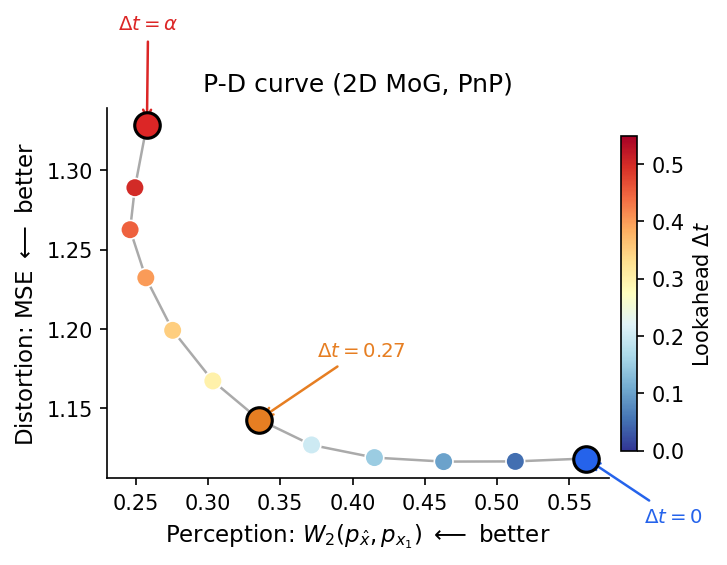

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import csv

np.random.seed(42)

# =============================================================================
# Setup (same as figure)
# =============================================================================
mu_a = np.array([4.5, 3.5])
mu_b = np.array([3.5, 5.5])
sigma_c = 0.35

n_pts = 200
labels_mix = np.random.binomial(1, 0.5, n_pts)
x1_samples = np.where(labels_mix[:, None],
                       mu_b + sigma_c * np.random.randn(n_pts, 2),
                       mu_a + sigma_c * np.random.randn(n_pts, 2))

theta_rot = np.pi / 6
scale_h = 0.8
H = scale_h * np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
                          [np.sin(theta_rot),  np.cos(theta_rot)]])
sigma_obs = 0.3

# Smaller test set for speed
n_test = 100
labels_test = np.random.binomial(1, 0.5, n_test)
x1_test = np.where(labels_test[:, None],
                    mu_b + sigma_c * np.random.randn(n_test, 2),
                    mu_a + sigma_c * np.random.randn(n_test, 2))
y_test = (H @ x1_test.T).T + sigma_obs * np.random.randn(n_test, 2)

# =============================================================================
# MoG denoiser / flow map (same functions, fewer ODE steps)
# =============================================================================
def mog_denoiser(x, t):
    sig_t_sq = (1 - t)**2 + t**2 * sigma_c**2
    diff_a = x - t * mu_a
    diff_b = x - t * mu_b
    log_w_a = -0.5 * np.sum(diff_a**2) / sig_t_sq
    log_w_b = -0.5 * np.sum(diff_b**2) / sig_t_sq
    max_log = max(log_w_a, log_w_b)
    w_a = np.exp(log_w_a - max_log)
    w_b = np.exp(log_w_b - max_log)
    w_sum = w_a + w_b
    w_a /= w_sum; w_b /= w_sum
    A_t = t * sigma_c**2 / sig_t_sq
    return w_a * (mu_a + A_t * (x - t * mu_a)) + w_b * (mu_b + A_t * (x - t * mu_b))

def mog_velocity(x, t):
    if t > 0.9999: t = 0.9999
    D = mog_denoiser(x, t)
    return (D - x) / (1 - t)

def simulate_flow(x_start, s, t, n_steps=80):
    x = x_start.copy()
    dt = (t - s) / n_steps
    for i in range(n_steps):
        tau = s + i * dt
        x = x + dt * mog_velocity(x, tau)
    return x

def flow_map_denoiser(x, s, t):
    if np.abs(t - s) < 1e-10:
        return mog_denoiser(x, s)
    x_t = simulate_flow(x, s, t, n_steps=80)
    v_avg = (x_t - x) / (t - s)
    return x + (1 - s) * v_avg

def pnp_flow_map(y, s, t_lookahead, n_iters=40):
    H_inv = np.linalg.inv(H)
    x = H_inv @ y
    for k in range(n_iters):
        gamma = 0.4 * (1.0 - k / n_iters)**0.5
        grad = (H.T @ (H @ x - y)) / (sigma_obs**2)
        z = x - gamma * grad
        eps = np.random.randn(2)
        z_tilde = (1 - s) * eps + s * z
        x = flow_map_denoiser(z_tilde, s, t_lookahead)
    return x

def empirical_w2(samples_a, samples_b):
    n = min(len(samples_a), len(samples_b))
    cost = cdist(samples_a[:n], samples_b[:n], metric='sqeuclidean')
    row_ind, col_ind = linear_sum_assignment(cost)
    return np.sqrt(cost[row_ind, col_ind].mean())

# =============================================================================
# Sweep
# =============================================================================
s_val = 0.45
lookahead_values = np.linspace(s_val, 1.0, 12)

print(f"Sweeping {len(lookahead_values)} lookahead values, {n_test} test points each...")
results = []

for i, t_val in enumerate(lookahead_values):
    print(f"  [{i+1}/{len(lookahead_values)}] t = {t_val:.3f}...", end='', flush=True)
    outputs = []
    for j in range(n_test):
        np.random.seed(2000 + j)
        outputs.append(pnp_flow_map(y_test[j], s_val, t_val))
    outputs = np.array(outputs)
    
    mse = np.mean(np.sum((outputs - x1_test)**2, axis=1))
    w2 = empirical_w2(outputs, x1_samples)
    var_ratio = np.var(outputs) / np.var(x1_samples)
    delta_t = t_val - s_val
    
    results.append({'t': t_val, 'delta_t': delta_t, 'mse': mse, 'w2': w2, 'var_ratio': var_ratio})
    print(f" MSE={mse:.4f}, W2={w2:.4f}, VR={var_ratio:.3f}")

print("Done.\n")

# =============================================================================
# Plot
# =============================================================================
mses = [r['mse'] for r in results]
w2s = [r['w2'] for r in results]
delta_ts = [r['delta_t'] for r in results]

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)

ax.plot(w2s, mses, '-', color='#AAAAAA', linewidth=1.2, zorder=1)
sc = ax.scatter(w2s, mses, c=delta_ts, cmap='RdYlBu_r', s=80, zorder=3,
                edgecolors='white', linewidths=0.8)

# Mark the 3 operating points from the teaser figure
highlight_ts = [s_val, 0.72, 1.0]
highlight_labels = [r'$\Delta t=0$', r'$\Delta t=0.27$', r'$\Delta t=\alpha$']
highlight_colors = ['#2563EB', '#E67E22', '#DC2626']

for ht, hl, hc in zip(highlight_ts, highlight_labels, highlight_colors):
    # Find closest result
    idx = np.argmin([abs(r['t'] - ht) for r in results])
    ax.scatter(w2s[idx], mses[idx], c=hc, s=150, zorder=5,
               edgecolors='black', linewidths=1.5, marker='o')
    
    # Offset annotations to avoid overlap
    if ht == s_val:
        ax.annotate(hl, xy=(w2s[idx], mses[idx]),
                    xytext=(w2s[idx] + 0.04, mses[idx] - 0.04),
                    fontsize=9.5, fontweight='bold', color=hc,
                    arrowprops=dict(arrowstyle='->', color=hc, lw=1.2))
    elif ht == 1.0:
        ax.annotate(hl, xy=(w2s[idx], mses[idx]),
                    xytext=(w2s[idx] - 0.02, mses[idx] + 0.06),
                    fontsize=9.5, fontweight='bold', color=hc,
                    arrowprops=dict(arrowstyle='->', color=hc, lw=1.2))
    else:
        ax.annotate(hl, xy=(w2s[idx], mses[idx]),
                    xytext=(w2s[idx] + 0.04, mses[idx] + 0.04),
                    fontsize=9.5, fontweight='bold', color=hc,
                    arrowprops=dict(arrowstyle='->', color=hc, lw=1.2))

cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label(r'Lookahead $\Delta t$', fontsize=10)

ax.set_xlabel(r'Perception: $W_2(p_{\hat{x}}, p_{x_1})$ $\longleftarrow$ better', fontsize=11)
ax.set_ylabel(r'Distortion: MSE $\longleftarrow$ better', fontsize=11)
ax.set_title(r'P-D curve (2D MoG, PnP)', fontsize=12, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pd_curve_pnp_mog.pdf', bbox_inches='tight', dpi=300)
# Save CSV
# with open('/home/claude/pd_curve_data.csv', 'w', newline='') as f:
#     writer = csv.DictWriter(f, fieldnames=['t', 'delta_t', 'mse', 'w2', 'var_ratio'])
#     writer.writeheader()
#     writer.writerows(results)

print("Saved: pd_curve_pnp_mog.pdf, pd_curve_pnp_mog.png, pd_curve_data.csv")

     t   Lambda(s,t)      m(t)      c(t)   ||PnP - theory|| mean
-----------------------------------------------------------------
  0.45      1.617978    0.7281    0.3735               8.332e-18
  0.72      1.796116    0.8083    0.2372               2.054e-17
  1.00      1.896182    0.8533    0.1719               3.327e-17

Saved: gaussian_tikhonov_validation.pdf


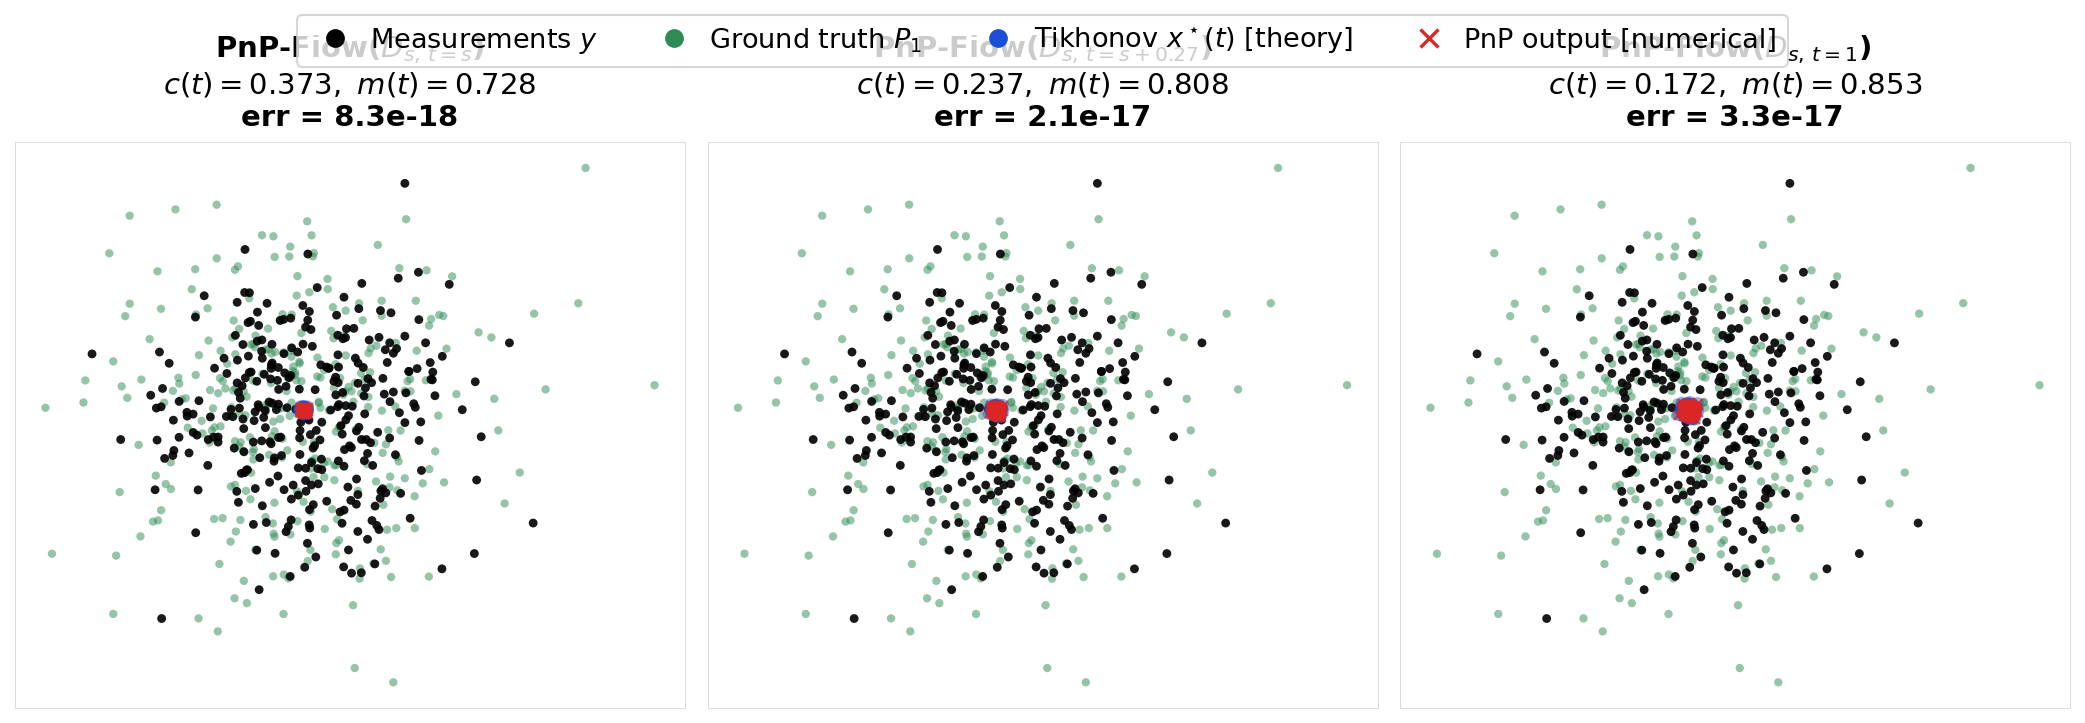

In [28]:
# =============================================================================
# Gaussian case: validate the Tikhonov fixed-point solution (eq. tikhonov)
# =============================================================================
# For a Gaussian prior P1 = N(0, sigma_p^2 I), the flow-map denoiser is
# exactly linear: D_{s,t}(x) = Lambda(s,t) * x, with closed-form gain
#
#   Lambda(s,t) = 1 + (1-s) * (sigma_t/sigma_s - 1) / (t - s)
#
# The deterministic PnP fixed point satisfies:
#
#   x*(t) = (c(t)*I + lam*H^T H)^{-1} lam H^T y,   c(t) = 1/m(t) - 1
#
# where m(t) = s * Lambda(s,t).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

np.random.seed(7)

# --- Prior and forward model (same H as the MoG experiment) ---
sigma_p   = 2.0
d         = 2
s_val     = 0.45
lam       = 0.01          # gradient step parameter (= alpha / sigma_obs^2)

theta     = np.pi / 6
H         = 0.8 * np.array([[np.cos(theta), -np.sin(theta)],
                             [np.sin(theta),  np.cos(theta)]])
sigma_obs = 0.05

n_test   = 300
x1_true  = sigma_p * np.random.randn(n_test, d)
y_obs    = (H @ x1_true.T).T + sigma_obs * np.random.randn(n_test, d)
x1_ref   = sigma_p * np.random.randn(n_test, d)
# ---------------------------------------------------------------------------
# Analytic formulas
# ---------------------------------------------------------------------------
def sigma_t_sq(t):
    return (1.0 - t)**2 + t**2 * sigma_p**2

def Lambda_st(s, t):
    ss = np.sqrt(sigma_t_sq(s))
    st = np.sqrt(sigma_t_sq(t))
    if abs(t - s) < 1e-8:
        return t * sigma_p**2 / sigma_t_sq(t)
    return 1.0 + (1.0 - s) * (st / ss - 1.0) / (t - s)

def m_val(s, t):   return s * Lambda_st(s, t)
def c_val(s, t):   return 1.0 / m_val(s, t) - 1.0

def tikhonov_fp(y, s, t):
    ct = c_val(s, t)
    M  = ct * np.eye(d) + lam * H.T @ H
    return np.linalg.solve(M, lam * H.T @ y)

# ---------------------------------------------------------------------------
# Deterministic PnP (eps = 0): converges to the Tikhonov fixed point
# ---------------------------------------------------------------------------
def pnp_gauss_det(y, s, t, n_iters=400):
    Lam = Lambda_st(s, t)
    x   = np.linalg.solve(H, y)
    for _ in range(n_iters):
        z       = x - lam * H.T @ (H @ x - y)   # gradient step
        z_tilde = s * z                           # renoise, eps=0
        x       = Lam * z_tilde                   # linear denoiser
    return x

# ---------------------------------------------------------------------------
# Three lookahead cases
# ---------------------------------------------------------------------------
lookaheads = [s_val, 0.72, 1.0]
labels     = [
    r'PnP-Flow($D_{s,\,t=s}$)',
    r'PnP-Flow($D_{s,\,t=s+0.27}$)',
    r'PnP-Flow($D_{s,\,t=1}$)',
]

print(f"{'t':>6}  {'Lambda(s,t)':>12}  {'m(t)':>8}  {'c(t)':>8}  {'||PnP - theory|| mean':>22}")
print('-' * 65)

outputs_pnp    = {}
outputs_theory = {}

for t_val in lookaheads:
    Lam  = Lambda_st(s_val, t_val)
    mt   = m_val(s_val, t_val)
    ct   = c_val(s_val, t_val)

    pnp    = np.array([pnp_gauss_det(y_obs[i], s_val, t_val) for i in range(n_test)])
    theory = np.array([tikhonov_fp(y_obs[i], s_val, t_val)   for i in range(n_test)])

    err = np.mean(np.linalg.norm(pnp - theory, axis=1))
    print(f"{t_val:>6.2f}  {Lam:>12.6f}  {mt:>8.4f}  {ct:>8.4f}  {err:>22.3e}")

    outputs_pnp[t_val]    = pnp
    outputs_theory[t_val] = theory

# ---------------------------------------------------------------------------
# Plot (same palette as the MoG teaser in cell 1)
# ---------------------------------------------------------------------------
c_data   = '#2E8B57'   # green  -- ground truth P1
c_latent = '#000000'   # black  -- measurements y
c_pnp    = '#DC2626'   # red    -- PnP output
c_theory = '#1D4ED8'   # blue   -- Tikhonov theory

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)

for idx, (t_val, label) in enumerate(zip(lookaheads, labels)):
    ax  = axes[idx]
    th  = outputs_theory[t_val]
    pnp = outputs_pnp[t_val]

    # Ground truth P1 samples (green)
    ax.scatter(x1_ref[:, 0], x1_ref[:, 1], c=c_data, alpha=0.5, s=16,
               edgecolors='none', zorder=1)
    # Measurements y (black, strong)
    ax.scatter(y_obs[:, 0], y_obs[:, 1], c=c_latent, alpha=0.9, s=18,
               edgecolors='none', zorder=2)
    # Tikhonov theory (blue)
    ax.scatter(th[:, 0], th[:, 1], c=c_theory, alpha=0.45, s=36,
               edgecolors='none', zorder=3, marker='o')
    # PnP numerical (red, x marker on top of the theory markers)
    ax.scatter(pnp[:, 0], pnp[:, 1], c=c_pnp, alpha=0.8, s=18,
               linewidths=1.0, zorder=4, marker='x')

    ct  = c_val(s_val, t_val)
    mt  = m_val(s_val, t_val)
    err = np.mean(np.linalg.norm(pnp - th, axis=1))

    # Build title pieces separately to avoid format-string conflicts with
    # LaTeX braces in the label.
    stats = r'$c(t)={:.3f},\ m(t)={:.3f}$'.format(ct, mt)
    err_str = 'err = {:.1e}'.format(err)
    ax.set_title(label + '\n' + stats + '\n' + err_str,
                 fontsize=14, fontweight='bold', pad=8)

    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color('#DDDDDD')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_latent, markersize=9,
           label=r'Measurements $y$', markeredgecolor='none'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_data, markersize=9,
           label=r'Ground truth $P_1$', markeredgecolor='none'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_theory, markersize=9,
           label=r'Tikhonov $x^\star(t)$ [theory]', markeredgecolor='none'),
    Line2D([0],[0], marker='x', color=c_pnp, markersize=9, markeredgewidth=1.6,
           label=r'PnP output [numerical]', linestyle='None'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=13,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, 1.02),
           edgecolor='#CCCCCC', handletextpad=0.3, columnspacing=1.8)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig('gaussian_tikhonov_validation.pdf', bbox_inches='tight', dpi=300)
print('\nSaved: gaussian_tikhonov_validation.pdf')


H2 =
[[ 0.50630642 -0.71843845]
 [ 0.53726512 -0.16984166]]
H2^T H2 =
[[ 0.545 -0.455]
 [-0.455  0.545]]
eigenvalues of H2^T H2: [0.09 1.  ]   (condition number = 11.11)
lam = 0.5, 2/||H2^T H2|| = 2.000   -> contraction
Optimal Wiener regularisation  alpha* = (sigma_obs/sigma_p)^2 = 0.000625

     t   c(t)/lam     alpha*    MSE(PnP,x1)  MSE(Renoise,x1)    MSE(MAP,x1)    ||PnP-theory||
--------------------------------------------------------------------------------------
  0.45     0.7469     0.0006         3.6692         7.7886         0.0308          2.56e-16
  0.72     0.4745     0.0006         3.0164         7.7874         0.0308          3.59e-16
  1.00     0.3439     0.0006         2.5756         7.8020         0.0308          4.84e-16

Saved: gaussian_tikhonov_validation_H2.pdf
Saved: gaussian_shrinkage_arrows_H2.pdf


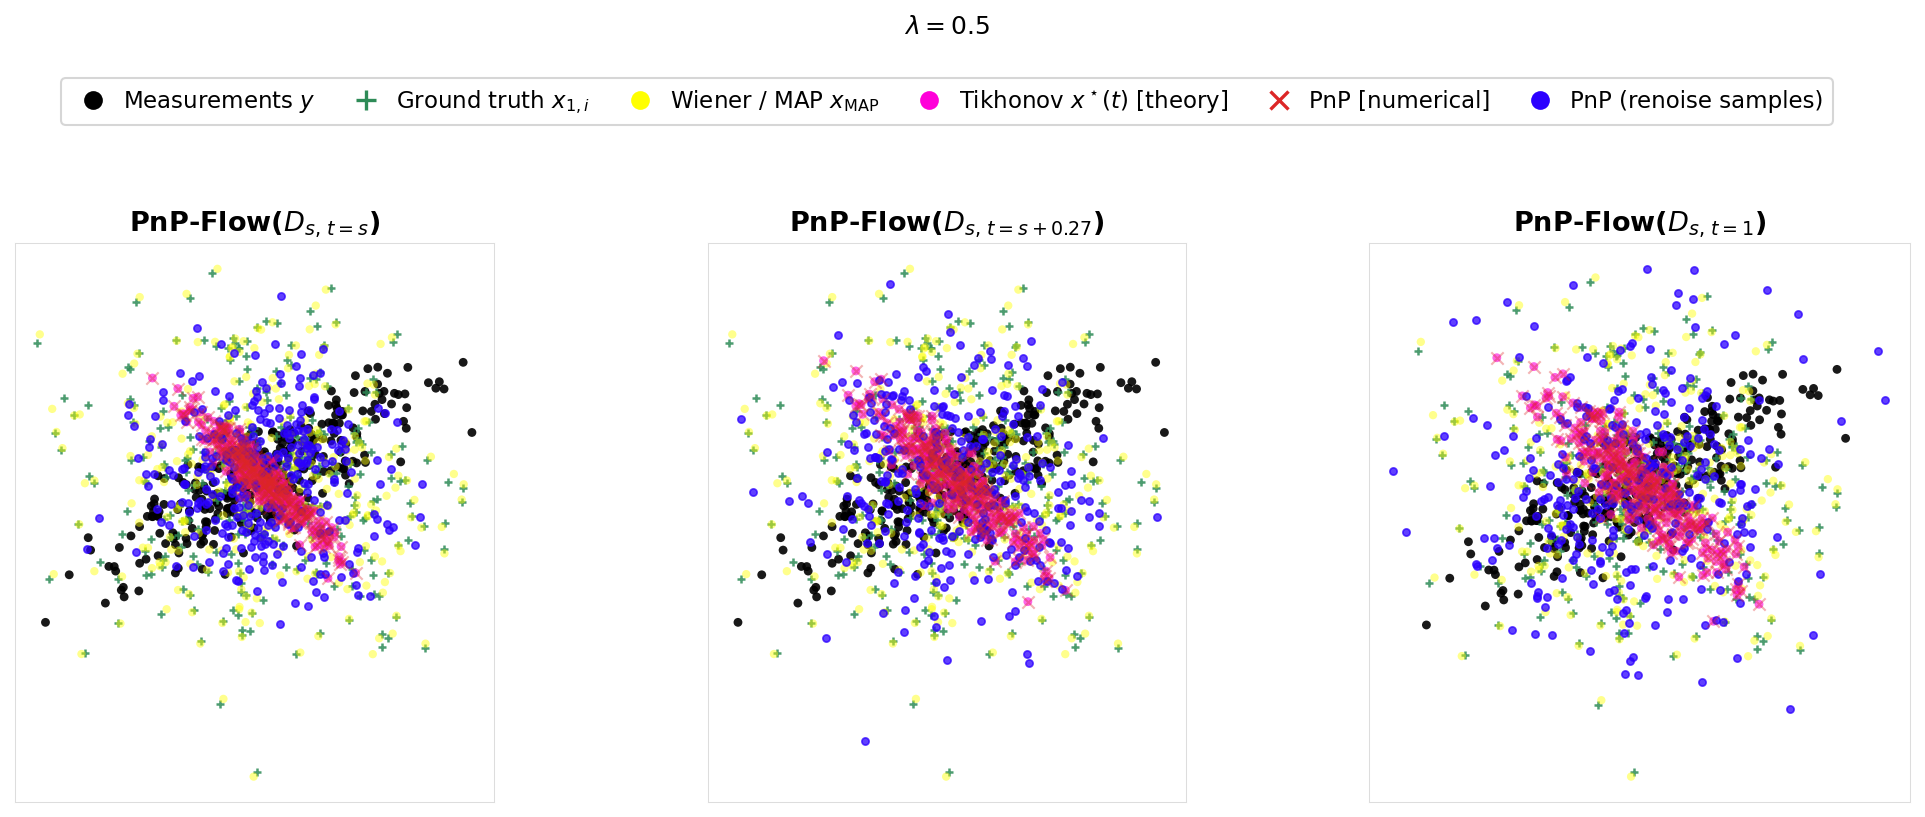

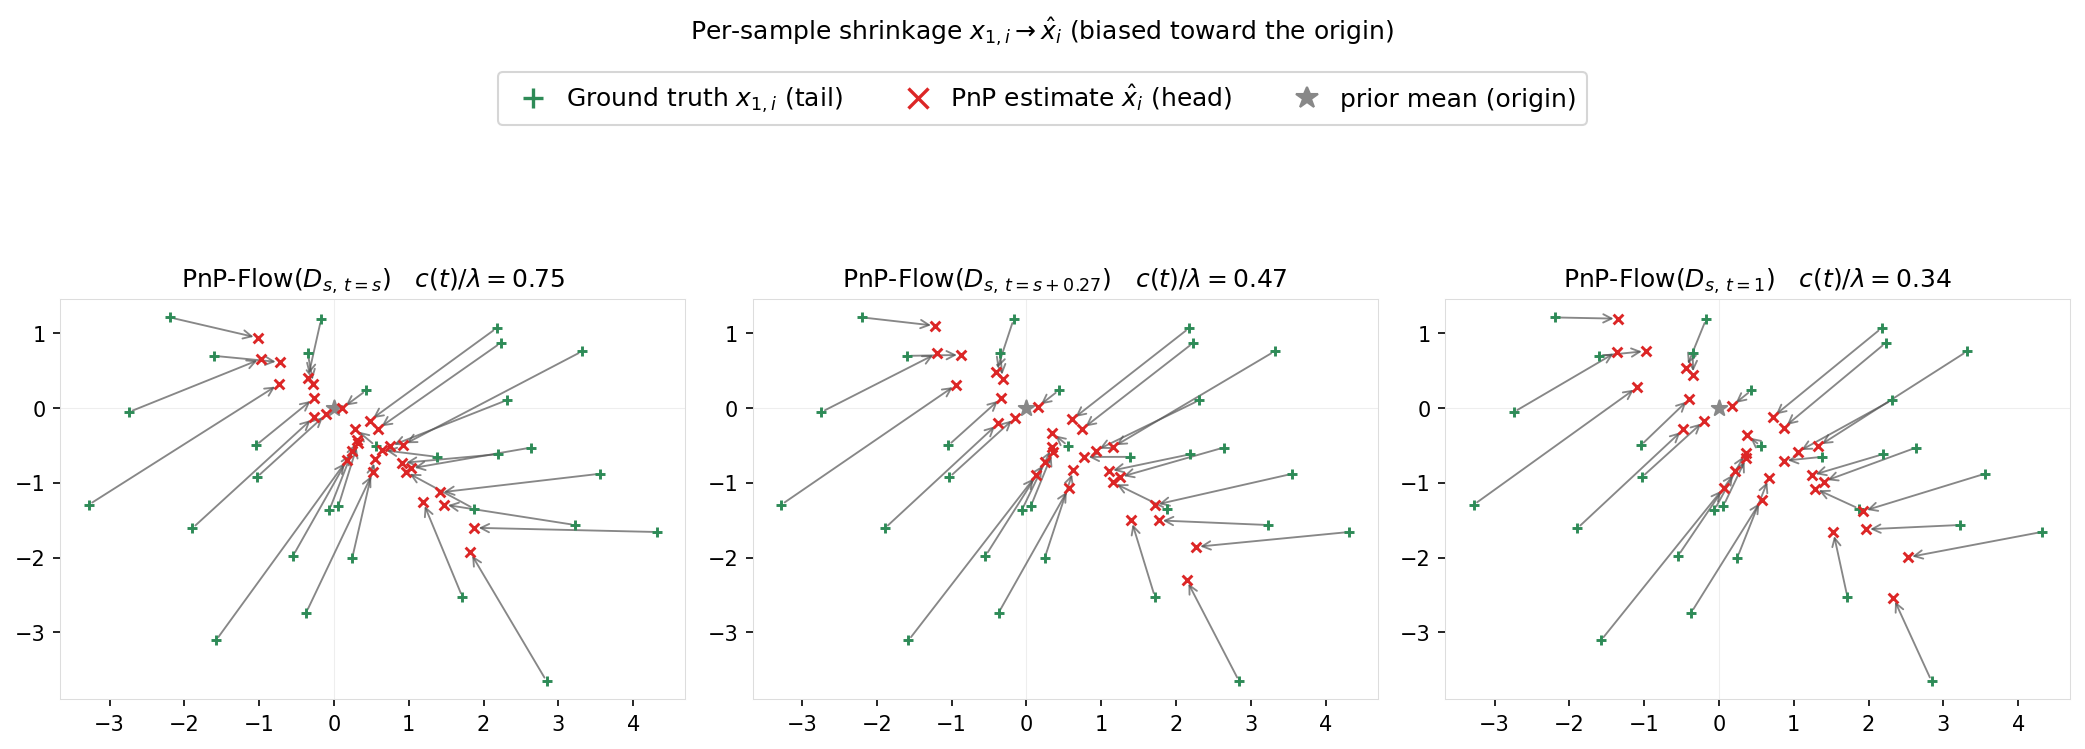

In [ ]:
# =============================================================================
# Gaussian case, part 2: anisotropic & correlating forward model H2
# =============================================================================
# Same analytic machinery as the previous cell -- but with a harder H that
# mixes the two coordinates:
#
#     H2 = R(theta1) @ diag(a, b) @ R(theta2),    a != b, theta2 != 0
#
# so that H2^T H2 is off-diagonal in the standard basis (coordinates are
# correlated) and the condition number (a/b)^2 >> 1 makes the inverse problem
# more ill-posed.  We additionally plot the per-sample ground truth x1_i and
# the optimal Wiener/MAP estimator as a reference, and we produce a second
# figure showing the per-sample shrinkage vectors x1_true -> x_PnP.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

np.random.seed(11)

# ---------------------------------------------------------------------------
# Build the harder H2  (reuses sigma_p, sigma_obs, lam, s_val from prev cell)
# ---------------------------------------------------------------------------
def rot(th):
    return np.array([[np.cos(th), -np.sin(th)],
                     [np.sin(th),  np.cos(th)]])

theta1, theta2 = np.pi/6, np.pi/4
a, b           = 1.0, 0.3
H2             = rot(theta1) @ np.diag([a, b]) @ rot(theta2)

eigvals = np.linalg.eigvalsh(H2.T @ H2)
print('H2 =')
print(H2)
print('H2^T H2 =')
print(H2.T @ H2)
print(f'eigenvalues of H2^T H2: {eigvals}   (condition number = {eigvals.max()/eigvals.min():.2f})')

# ---------------------------------------------------------------------------
# Data with the new forward model
# ---------------------------------------------------------------------------
n_test2  = 300
x1_true2 = sigma_p * np.random.randn(n_test2, d)
y_obs2   = (H2 @ x1_true2.T).T + sigma_obs * np.random.randn(n_test2, d)
x1_ref2  = sigma_p * np.random.randn(n_test2, d)   # background reference cloud
lam = 0.5 #0.1
max_eig = eigvals.max()
print(f'lam = {lam}, 2/||H2^T H2|| = {2/max_eig:.3f}   -> contraction' if lam < 2/max_eig else 'lam too big')

# ---------------------------------------------------------------------------
# Theory / deterministic PnP / Wiener reference
# ---------------------------------------------------------------------------
def tikhonov_fp_H(y, s, t, H_mat):
    ct = c_val(s, t)
    M  = ct * np.eye(d) + lam * H_mat.T @ H_mat
    return np.linalg.solve(M, lam * H_mat.T @ y)

def pnp_gauss_det_H(y, s, t, H_mat, n_iters=600):
    Lam = Lambda_st(s, t)
    x   = np.linalg.solve(H_mat, y)
    for _ in range(n_iters):
        z       = x - lam * H_mat.T @ (H_mat @ x - y)
        z_tilde = s * z
        x       = Lam * z_tilde
    return x

def pnp_gauss_stochastic_H(y, s, t, H_mat, n_iters=200, n_runs=50):
    Lam = Lambda_st(s, t)
    samples = []

    # for _ in range(n_runs):
    x = np.linalg.solve(H_mat, y) 

    for _ in range(n_iters):
        z = x - lam * H_mat.T @ (H_mat @ x - y)
        eps = np.random.randn(d)
        z_tilde = s * z + (1 - s) * eps
        x = Lam * z_tilde

        # samples.append(x)

    # return np.array(samples)
    return x

def wiener_map(y, H_mat, sig_p=sigma_p, sig_n=sigma_obs):
    # Posterior mean for  x ~ N(0, sig_p^2 I), y = H x + N(0, sig_n^2 I)
    # x_MAP = ( (sig_n/sig_p)^2 I + H^T H )^{-1} H^T y
    alpha_star = (sig_n / sig_p)**2
    M = alpha_star * np.eye(H_mat.shape[1]) + H_mat.T @ H_mat
    return np.linalg.solve(M, H_mat.T @ y)

alpha_star = (sigma_obs / sigma_p)**2
print(f'Optimal Wiener regularisation  alpha* = (sigma_obs/sigma_p)^2 = {alpha_star:.4g}')

# ---------------------------------------------------------------------------
# Run the three lookahead cases
# ---------------------------------------------------------------------------
lookaheads2 = [s_val, 0.72, 1.0]
labels2     = [
    r'PnP-Flow($D_{s,\,t=s}$)',
    r'PnP-Flow($D_{s,\,t=s+0.27}$)',
    r'PnP-Flow($D_{s,\,t=1}$)',
]

print(f"\n{'t':>6}  {'c(t)/lam':>9}  {'alpha*':>9}  {'MSE(PnP,x1)':>13}  {'MSE(Renoise,x1)':>13}  {'MSE(MAP,x1)':>13}  {'||PnP-theory||':>16}")
print('-' * 86)

outputs_pnp2    = {}
outputs_theory2 = {}

# Wiener reference (independent of t)
x_map = np.array([wiener_map(y_obs2[i], H2) for i in range(n_test2)])
mse_map = np.mean(np.sum((x_map - x1_true2)**2, axis=1))

for t_val in lookaheads2:
    ct = c_val(s_val, t_val)
    pnp    = np.array([pnp_gauss_det_H(y_obs2[i], s_val, t_val, H2) for i in range(n_test2)])
    pnp_renoise = np.array([pnp_gauss_stochastic_H(y_obs2[i], s_val, t_val, H2) for i in range(n_test2)])
    theory = np.array([tikhonov_fp_H(y_obs2[i],   s_val, t_val, H2) for i in range(n_test2)])

    err_fp  = np.mean(np.linalg.norm(pnp - theory, axis=1))
    mse_pnp = np.mean(np.sum((pnp - x1_true2)**2, axis=1))
    mse_renoise = np.mean(np.sum((pnp_renoise.mean(axis=0) - x1_true2)**2, axis=1))
    print(f'{t_val:>6.2f}  {ct/lam:>9.4f}  {alpha_star:>9.4f}  {mse_pnp:>13.4f}  {mse_renoise:>13.4f}  {mse_map:>13.4f}  {err_fp:>16.2e}')

    outputs_pnp2[t_val]    = pnp
    outputs_pnp2[f'{t_val}_renoise'] = pnp_renoise
    outputs_theory2[t_val] = theory

# ---------------------------------------------------------------------------
# FIGURE 1 -- estimators overlay (includes per-sample x1_true and Wiener MAP)
# ---------------------------------------------------------------------------
c_data   = '#2E8B57'   # green  -- P_1 distribution and per-sample ground truth x1_i
c_latent = '#000000'   # black  -- measurements y
c_pnp    = '#DC2626'   # red    -- PnP output
c_renoise = "#2B00FF"   # red    -- PnP renoise samples (lighter)
c_theory = "#FF00D9"   # blue   -- Tikhonov theory
c_map    = "#FFFF00"   # orange -- optimal Wiener / MAP reference

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)

for idx, (t_val, label) in enumerate(zip(lookaheads2, labels2)):
    ax  = axes[idx]
    th  = outputs_theory2[t_val]
    pnp = outputs_pnp2[t_val]
    pnp_renoise = outputs_pnp2[f'{t_val}_renoise']
    # Background P1 reference cloud
    # ax.scatter(x1_ref2[:, 0],  x1_ref2[:, 1],  c=c_data,   alpha=0.18, s=14,
    #            edgecolors='none', zorder=1)
    # Measurements y (strong)
    ax.scatter(y_obs2[:, 0],   y_obs2[:, 1],   c=c_latent, alpha=0.9,  s=18,
               edgecolors='none', zorder=2)
    # Per-sample ground truth x1_i (green + marker)
    ax.scatter(x1_true2[:, 0], x1_true2[:, 1], c=c_data,   alpha=0.85, s=18,
               marker='+', linewidths=1.2, zorder=2)
    # Wiener / MAP reference (orange dot)
    ax.scatter(x_map[:, 0],    x_map[:, 1],    c=c_map,    alpha=0.45, s=16,
               edgecolors='none', zorder=2, marker='o')
    # Tikhonov theory (blue)
    ax.scatter(th[:, 0],       th[:, 1],       c=c_theory, alpha=0.60, s=18,
               edgecolors='none', zorder=3, marker='o')
    # PnP numerical (red x on top)
    ax.scatter(pnp[:, 0],      pnp[:, 1],      c=c_pnp,    alpha=0.35, s=35,
               linewidths=1.0, zorder=4, marker='x')
    ax.scatter(pnp_renoise[:, 0], pnp_renoise[:, 1], c=c_renoise, alpha=0.75, s=12,
               linewidths=0.8, zorder=3, marker='o')

    ct  = c_val(s_val, t_val)
    mt  = m_val(s_val, t_val)
    err = np.mean(np.linalg.norm(pnp - th, axis=1))

    stats   = r'$c(t)/\lambda={:.3f},\ \alpha^\star={:.3g}$'.format(ct/lam, alpha_star)
    err_str = 'err = {:.1e}'.format(err)
    ax.set_title(label, 
                 fontsize=13, fontweight='bold', pad=6)
# + '\n' + stats + '\n' + err_str,
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color('#DDDDDD')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_latent, markersize=9,
           label=r'Measurements $y$', markeredgecolor='none'),
    # Line2D([0],[0], marker='o', color='w', markerfacecolor=c_data, markersize=9,
    #        label=r'$P_1$ samples', markeredgecolor='none'),
    Line2D([0],[0], marker='+', color=c_data, markersize=10, markeredgewidth=1.6,
           label=r'Ground truth $x_{1,i}$', linestyle='None'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_map, markersize=9,
           label=r'Wiener / MAP $x_{\mathrm{MAP}}$', markeredgecolor='none'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_theory, markersize=9,
           label=r'Tikhonov $x^\star(t)$ [theory]', markeredgecolor='none'),
    Line2D([0],[0], marker='x', color=c_pnp, markersize=9, markeredgewidth=1.6,
           label=r'PnP [numerical]', linestyle='None'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c_renoise, markersize=9,
           label=r'PnP (renoise samples)', linestyle='None', markeredgecolor='none'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=6, fontsize=11,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, 1.03),
           edgecolor='#CCCCCC', handletextpad=0.3, columnspacing=1.2)

plt.suptitle(
    r'$\lambda = $' + f'{lam}',
    fontsize=12, y=1.10
)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig('gaussian_tikhonov_validation_H2.pdf', bbox_inches='tight', dpi=300)
print('\nSaved: gaussian_tikhonov_validation_H2.pdf')

# ---------------------------------------------------------------------------
# FIGURE 2 -- per-sample shrinkage arrows  x1_true -> x_PnP
# ---------------------------------------------------------------------------
n_arrow = 30                             # subsample to keep arrows readable
rng_idx = np.random.default_rng(3).choice(n_test2, n_arrow, replace=False)

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5), dpi=150)
for idx, (t_val, label) in enumerate(zip(lookaheads2, labels2)):
    ax  = axes2[idx]
    pnp = outputs_pnp2[t_val][rng_idx]
    gt  = x1_true2[rng_idx]

    # Origin marker
    ax.scatter([0], [0], c='#888888', s=60, marker='*', zorder=2,
               label='prior mean (origin)')
    # Tails = ground truth, heads = PnP estimate
    for gi, pi in zip(gt, pnp):
        ax.annotate('', xy=pi, xytext=gi,
                    arrowprops=dict(arrowstyle='->', color='#555555',
                                    lw=0.9, alpha=0.7))
    ax.scatter(gt[:, 0],  gt[:, 1],  c=c_data, s=22, marker='+',
               linewidths=1.4, zorder=3)
    ax.scatter(pnp[:, 0], pnp[:, 1], c=c_pnp,  s=22, marker='x',
               linewidths=1.4, zorder=3)

    ct = c_val(s_val, t_val)
    ax.set_title(label + r'   $c(t)/\lambda={:.2f}$'.format(ct/lam),
                 fontsize=12, pad=6)
    ax.set_aspect('equal')
    ax.axhline(0, color='#EEEEEE', lw=0.5, zorder=0)
    ax.axvline(0, color='#EEEEEE', lw=0.5, zorder=0)
    for sp in ax.spines.values():
        sp.set_linewidth(0.5); sp.set_color('#DDDDDD')

arrow_legend = [
    Line2D([0],[0], marker='+', color=c_data, markersize=10, markeredgewidth=1.6,
           label=r'Ground truth $x_{1,i}$ (tail)', linestyle='None'),
    Line2D([0],[0], marker='x', color=c_pnp,  markersize=10, markeredgewidth=1.6,
           label=r'PnP estimate $\hat{x}_i$ (head)', linestyle='None'),
    Line2D([0],[0], marker='*', color='#888888', markersize=11,
           label='prior mean (origin)', linestyle='None'),
]
fig2.legend(handles=arrow_legend, loc='upper center', ncol=3, fontsize=12,
            frameon=True, fancybox=True, bbox_to_anchor=(0.5, 1.02),
            edgecolor='#CCCCCC', handletextpad=0.3, columnspacing=2.0)
plt.suptitle('Per-sample shrinkage $x_{1,i} \\to \\hat{x}_i$ (biased toward the origin)',
             fontsize=12, y=1.08)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig('gaussian_shrinkage_arrows_H2.pdf', bbox_inches='tight', dpi=300)
print('Saved: gaussian_shrinkage_arrows_H2.pdf')


In [16]:
# =============================================================================
# STOCHASTIC PnP (with renoising) -- reveals DP behavior
# =============================================================================

def pnp_gauss_stochastic_H(y, s, t, H_mat, n_iters=200, n_runs=50):
    Lam = Lambda_st(s, t)
    samples = []

    for _ in range(n_runs):
        x = np.linalg.solve(H_mat, y)

        for _ in range(n_iters):
            z = x - lam * H_mat.T @ (H_mat @ x - y)
            eps = np.random.randn(d)
            z_tilde = s * z + (1 - s) * eps
            x = Lam * z_tilde

        samples.append(x)

    return np.array(samples)


print("\n--- STOCHASTIC PnP (with renoising) ---")
print(f"{'t':>6}  {'MSE':>10}  {'Var':>10}")

outputs_stoch = {}

for t_val in lookaheads2:
    all_samples = []

    # run stochastic PnP for each observation
    for i in range(n_test2):
        samples_i = pnp_gauss_stochastic_H(y_obs2[i], s_val, t_val, H2, n_runs=20)
        all_samples.append(samples_i)

    all_samples = np.array(all_samples)  # shape: (N, runs, d)

    # mean estimate
    mean_est = np.mean(all_samples, axis=1)

    # distortion (MSE vs ground truth)
    mse = np.mean(np.sum((mean_est - x1_true2)**2, axis=1))

    # perception proxy = variance of samples
    var = np.mean(np.var(all_samples, axis=1))

    print(f"{t_val:6.2f}  {mse:10.4f}  {var:10.4f}")

    outputs_stoch[t_val] = all_samples


--- STOCHASTIC PnP (with renoising) ---
     t         MSE         Var
  0.45      4.1191      1.2157
  0.72      3.6207      1.7983
  1.00      3.0270      2.2738
